In [100]:
using CSVFiles

In [101]:
using LinearAlgebra
using DataFrames
using DataFrames
using Measurements
import Measurements: value, uncertainty

In [102]:
##alles was hier kommt sind nur rundungsfunktionen und eine voreinstellung für die Achsenbeschriftung


using CSV
using CSVFiles
using CairoMakie

using DataFrames
using Measurements
import Measurements: value, uncertainty
using Statistics



using Random, Statistics

function first_significant_digit(x::Real)
    x == 0 && return 0  # Sonderfall: Wenn x genau 0 ist, gibt es keine signifikante Stelle, also gib 0 zurück.

    absx = abs(x)  # Der Betrag der Zahl wird genommen, damit negative Vorzeichen ignoriert werden.

    # Berechne die Zehnerpotenz, in der sich die erste signifikante Stelle befindet.
    # log10(absx) gibt den dekadischen Logarithmus. floor(Int, ...) rundet nach unten auf ganze Zahl.
    exponent = floor(Int, log10(absx))

    # Teile absx durch 10^exponent, um die Zahl in den Bereich [1,10) zu bringen
    # Beispiel: aus 456 → 4.56, aus 0.00456 → 4.56
    significand = absx / 10.0^exponent

    # Jetzt holen wir die ganzzahlige Ziffer vor dem Komma, das ist die erste signifikante Ziffer
    return floor(Int, significand)
end


"""
    round_measurement(m::Measurement; sigdigits_error::Int=1)

Rundet erst die Unsicherheit von `m` auf `sigdigits_error` signifikante Stellen
und rundet dann den Messwert auf dieselbe Genauigkeit (Dezimalstellen),
liefert einen neuen `Measurement`. Sigdigits_error wird automatisch auf den richtigen wert gesetzt durch if bedingung 
wenn first sig digit =1 oder 2, wird eine weitere stelle hinzugenommen.

input: ein measurement, output: ein measurement. Kann punktweise angewendet werden
"""
function round_measurement(m::Measurement)
    # 1) Unsicherheit extrahieren und auf sigdigits_error sig. Stellen runden
    u = uncertainty(m)
    if first_significant_digit(u)<3
        sigdigits_error=2
    else
        sigdigits_error=1
    end
    #println(sigdigits_error)

    u_r = round(u; sigdigits=sigdigits_error)

    
    if u_r==0 #wenn gauß versagt, normalverteilung und stw
        

    # Ziehe N Stichproben aus einer Normalverteilung und berechne KINETISCHE ENERGIE!!!
    p_samples = randn(100_000) .* 0.05  # p ~ N(0, σp=0.05) kein plan warum, aber die 0.05 sind auf jkeden fall der fehler vorher

    # Berechne kinetische Energie für jede Probe
    E_samples = p_samples.^2 ./ (2)

    # Mittelwert und Standardabweichung der Energie
    E_mean = mean(E_samples)
    E_std = std(E_samples)
    
    u_r = round(E_std; sigdigits=sigdigits_error)
        #println(u_r)
    end
    
    
    
    
    
    # 2) Anzahl Dezimalstellen bestimmen:
    #    Wenn u_r = x * 10^e  (mit 1 ≤ x < 10), dann ist e = floor(log10(u_r))
    #    und wir benötigen -e  Dezimalstellen (für e ≤ 0)
    e = floor(Int, log10(u_r))
       # println(e)
    if first_significant_digit(u)<3
        dec = max(0, -e) +1
    else
        dec = max(0, -e)
    end
    #dec = max(0, -e)
    #println(dec, log(12,u_r))

    # 3) Wert runden und neuen Measurement erstellen
    v_r = round(value(m); digits=dec)
    return measurement(v_r, u_r)
end

# Beispiel
m = measurement(0.023456, 0.0120236789)
println("Original: ", value(m))                  # 1.23456 ± 0.06789
m2 = round_measurement(m)
println("Gerundet: ", value(m2))  # z.B. 1.23(7) → ±0.07, Wert 1.23




Original: 0.023456
Gerundet: 0.023


In [103]:

function generate_reflections(hmax,nth)
    sc  = Dict{Int, Vector{Tuple{Int,Int,Int}}}()
    bcc = Dict{Int, Vector{Tuple{Int,Int,Int}}}()
    fcc = Dict{Int, Vector{Tuple{Int,Int,Int}}}()

    for h in 0:hmax, k in 0:hmax, l in 0:hmax
        if h == 0 && k == 0 && l == 0
            continue
        else
        N = h^2 + k^2 + l^2
        hkl = (h,k,l)

        # --- SC: alle erlaubten Reflexe ---
        if length(sc) == nth
            if N < maximum(keys(sc))
                delete!(sc, maximum(keys(sc)))
            end
        end 

        if length(fcc) == nth
            if N < maximum(keys(fcc))
                delete!(fcc, maximum(keys(fcc)))
            end
        end 

        if length(bcc) == nth
            if N < maximum(keys(bcc))
                delete!(bcc, maximum(keys(bcc)))
            end
        end 


        if length(sc) < nth
            push!(get!(sc, N, Vector{Tuple{Int,Int,Int}}()), hkl)
        end

        # --- BCC: h+k+l gerade ---
        if length(bcc) < nth
            if (h + k + l) % 2 == 0
                push!(get!(bcc, N, Vector{Tuple{Int,Int,Int}}()), hkl) 
            end
        end

        # --- FCC: alle h,k,l entweder alle gerade oder alle ungerade ---
        if length(fcc) < nth
            if (h % 2 == k % 2 == l % 2)
                push!(get!(fcc, N, Vector{Tuple{Int,Int,Int}}()), hkl)
            end
        end
    end
    end
    sc_sorted = [(N, sc[N]) for N in sort(collect(keys(sc)))]
    bcc_sorted = [(N, bcc[N]) for N in sort(collect(keys(bcc)))]
    fcc_sorted = [(N, fcc[N]) for N in sort(collect(keys(fcc)))]
    return sc_sorted, bcc_sorted, fcc_sorted
end


generate_reflections (generic function with 1 method)

In [104]:
sc,bcc,fcc = generate_reflections(5,3)


([(1, [(0, 0, 1), (0, 1, 0), (1, 0, 0)]), (2, [(0, 1, 1), (1, 0, 1), (1, 1, 0)]), (3, [(1, 1, 1)])], [(2, [(0, 1, 1), (1, 0, 1), (1, 1, 0)]), (4, [(0, 0, 2), (0, 2, 0), (2, 0, 0)]), (6, [(2, 1, 1)])], [(3, [(1, 1, 1)]), (4, [(0, 0, 2), (0, 2, 0), (2, 0, 0)]), (8, [(2, 2, 0)])])

In [105]:
sc_sorted = [(N, sc[N]) for N in sort(collect(keys(sc)))]
bcc_sorted = [(N, bcc[N]) for N in sort(collect(keys(bcc)))]
fcc_sorted = [(N, fcc[N]) for N in sort(collect(keys(fcc)))]

3-element Vector{Tuple{Int64, Tuple{Int64, Vector{Tuple{Int64, Int64, Int64}}}}}:
 (1, (3, [(1, 1, 1)]))
 (2, (4, [(0, 0, 2), (0, 2, 0), (2, 0, 0)]))
 (3, (8, [(2, 2, 0)]))

In [106]:
function table(th)
    row1 = round_measurement.(th ./2)
    row2 = round_measurement.(sin.((th ./2).*pi ./180))
    sc, bcc, fcc = generate_reflections(length(th)*2, length(th))
    row3 = []
    row4 = []
    row5 = []
    row6 = []
    row7 = []
    row8 = []
    for i in 1:min(length(sc), length(bcc), length(fcc))
        push!(row3, sc[i][2][1])
        push!(row4, round(sqrt(sc[i][1]), sigdigits=3))

        push!(row5, bcc[i][2][1])
        push!(row6, round(sqrt(bcc[i][1]), sigdigits=3))
        
        push!(row7, fcc[i][2][1])
        push!(row8, round(sqrt(fcc[i][1]), sigdigits=3))
    end
    DataFrame(θ=row1, sinθ=row2, sc=row3, sqrtsc=row4, bcc=row5, sqrtbcc=row6, fcc=row7, sqrtfcc=row8)
end


table (generic function with 1 method)

In [107]:
t=table(measurement.([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360],0.1))
(th = t[:,2])
(root = t[:,8])
delth = 0


0

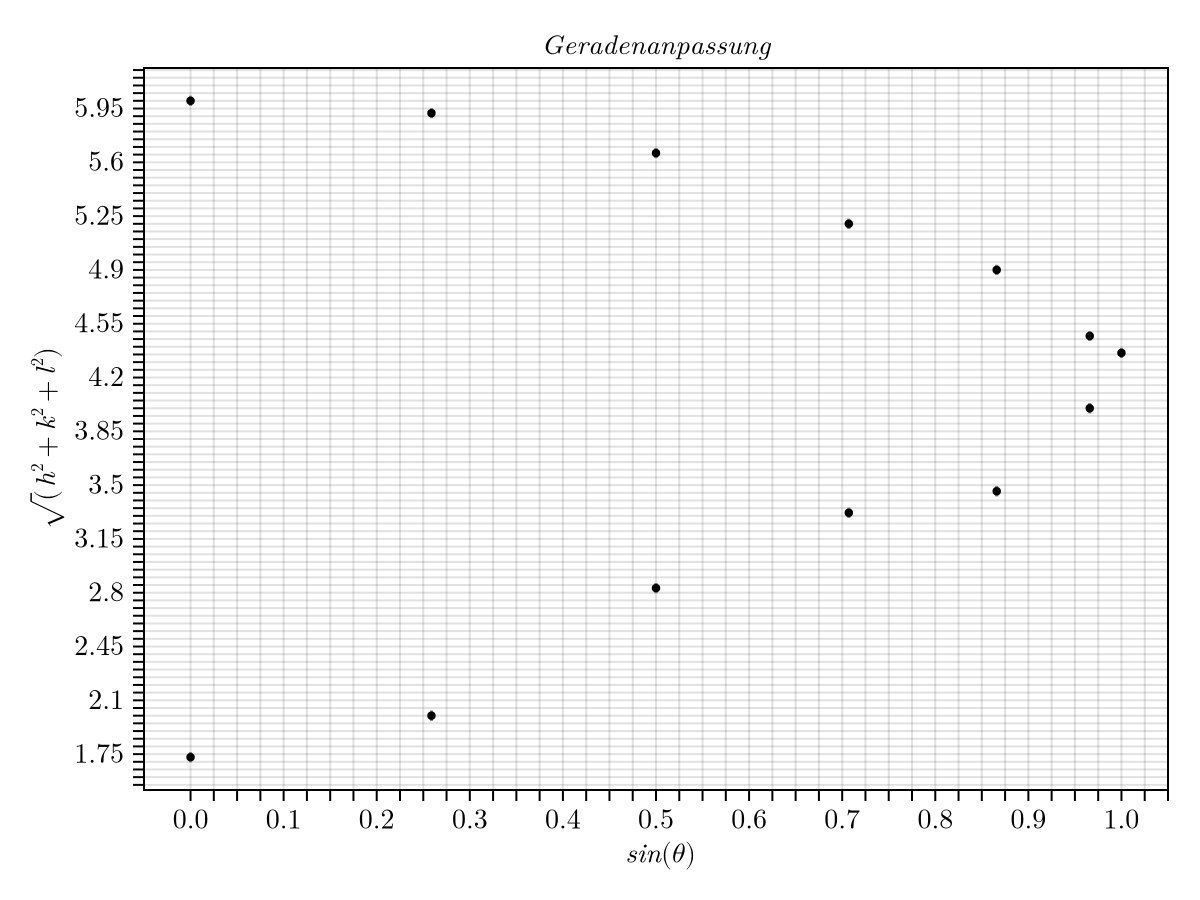

In [108]:
function nice_ticks_and_labels(x; n_ticks=20, n_labels=21, sigdigit=8)
    order = Float64(floor(Int, log10(maximum(x))))
    n = Float64(floor(Int, maximum(x) / 10^order))+1  # erste Ziffer
    tick_max = n * 10^order

    # Tick-Positionen: 0, 1*10^order, 2*10^order, ..., n*10^order
    ticks = round.(collect((0:100/n_ticks*10^(order-2):tick_max)) ; digits =sigdigit)  # feinere Tick-Striche

    # Beschriftete Zahlen: 10 gleichmäßig
    labels = collect(range(0, stop=tick_max, length=n_labels))

    return ticks, labels
end

function alignedlabels(ticks, labels; atol=0.01)
    aligned = String[]
    for x in ticks
        match = findfirst(lbl -> isapprox(x, lbl; atol=atol, rtol=0), labels)
        if match === nothing
            push!(aligned, "")
        else
            push!(aligned, string(labels[match]))
        end
    end
    return aligned
end






x = value.(th)##ANPASSEN##
y = root ##ANPASSEN##
#Fehler-Array mit gleichem Fehler
Δx= delth
Δy= 0   
#=for i in 1:length(x)
    push!(Δx,ΔV) ###ANPASSEN##
    push!(Δy,ΔT) ##ANPASSEN##
end=#
#=for i in 1:length(x)
    push!(Δx,ΔV) ###ANPASSEN##
    push!(Δy,ΔT) ##ANPASSEN##
end=#

with_theme(theme_latexfonts()) do
    fig = Figure()
    ax = Axis(fig[1,1])
    #Fehlerbalken
    #errorbars!(ax, x, y, Δy, color=:grey, whiskerwidth = 5)
    errorbars!(ax, x, y, Δx, color=:grey, whiskerwidth = 5, direction = :x)
    #Messwerte
    scatter!(ax,x, y, markersize = 6, color=:black)
    
    ax.title = L"$Geradenanpassung$" ##ANPASSEN##


    #Skalierung der x-Achse ##ANPASSEN##
xticks = nice_ticks_and_labels(x, n_labels=21, n_ticks=40)[1]
xticklabels = nice_ticks_and_labels(x, n_labels=21, n_ticks=40)[2]
aligned_xlabels = alignedlabels(xticks, xticklabels)
#Skalierung der y-Achse ##ANPASSEN##
yticks = nice_ticks_and_labels(y, n_labels=21)[1]
yticklabels = nice_ticks_and_labels(y, n_labels=21)[2]   
aligned_ylabels = alignedlabels(yticks, yticklabels)
ax.xlabel = L" $sin(\theta)$" ##ANPASSEN##
ax.ylabel = L"$\sqrt(h^2 +k^2 +l^2)$  " ##ANPASSEN##

ax.xticks = (xticks, aligned_xlabels)
ax.yticks = (yticks, aligned_ylabels) 

#axislegend(ax; position=(:left, :top))
    #plot speichern
    #save("Messung_E_A.png", fig, px_per_unit = 2) ##ANPASSEN##

    fig
end

In [109]:
using CSV


In [110]:
messung = (DataFrame(load("C:/Users/va/Uni/Praktikum/Praktikum_B/Festkörperphysik/Röntgennografische_Methoden/Gespeicherte_Fits/Probe_3_Gewichteter_Mittelwert_test.csv")))

Row,Peak_Label,Weighted_Mean_Theta,Error_Weighted_Mean_Theta
,Float64,Float64,Float64
1,38.71,19.3295,0.000273182
2,55.67,27.874,0.00159086
3,69.83,34.9157,0.00360222
4,82.68,41.332,0.00148338
5,95.01,47.5798,0.00216707
6,108.23,8.80168,0.119749
7,122.06,60.7522,0.586704


In [111]:

Probe_1 = measurement.(messung[:,1], messung[:,2])


7-element Vector{Measurement{Float64}}:
  39.0 ± 19.0
  56.0 ± 28.0
  70.0 ± 35.0
  83.0 ± 41.0
  95.0 ± 48.0
 108.2 ± 8.8
 122.0 ± 61.0

In [112]:
werte= table(Probe_1)
th1 = werte[:,2]
sc  = werte[:,4]
bcc = werte[:,6]
fcc = werte[:,8]
save("Wertetabelle.csv", werte)
werte
#print(value.(th1))
#th1 = [0.24116, 0.277734, 0.389847, 0.45609, 0.476852, 0.54931, sin(36.5/180*pi), 0.61353, 0.67127,sin(45/180*pi), 0.77395, sin(53/180*pi)]

Row,θ,sinθ,sc,sqrtsc,bcc,sqrtbcc,fcc,sqrtfcc
,Measurem…,Measurem…,Any,Any,Any,Any,Any,Any
1,19.0±10.0,0.33±0.16,"(0, 0, 1)",1.0,"(0, 1, 1)",1.41,"(1, 1, 1)",1.73
2,28.0±14.0,0.47±0.22,"(0, 1, 1)",1.41,"(0, 0, 2)",2.0,"(0, 0, 2)",2.0
3,35.0±17.0,0.57±0.25,"(1, 1, 1)",1.73,"(1, 1, 2)",2.45,"(0, 2, 2)",2.83
4,41.0±21.0,0.66±0.27,"(0, 0, 2)",2.0,"(0, 2, 2)",2.83,"(1, 1, 3)",3.32
5,48.0±24.0,0.74±0.28,"(0, 1, 2)",2.24,"(0, 1, 3)",3.16,"(2, 2, 2)",3.46
6,54.0±4.0,0.81±0.05,"(1, 1, 2)",2.45,"(2, 2, 2)",3.46,"(0, 0, 4)",4.0
7,61.0±30.0,0.87±0.26,"(2, 2, 0)",2.83,"(3, 2, 1)",3.74,"(4, 2, 0)",4.47


In [113]:
using LsqFit



In [114]:
model(x, p) = p[1].*x .+ p[2]


model (generic function with 1 method)

Die Steigung von Probe 3 ist 4.298043506242043
Die Steigung von Probe 2 ist 3.2397991949683846
Die Steigung von Probe 1 ist 5.133865362310711


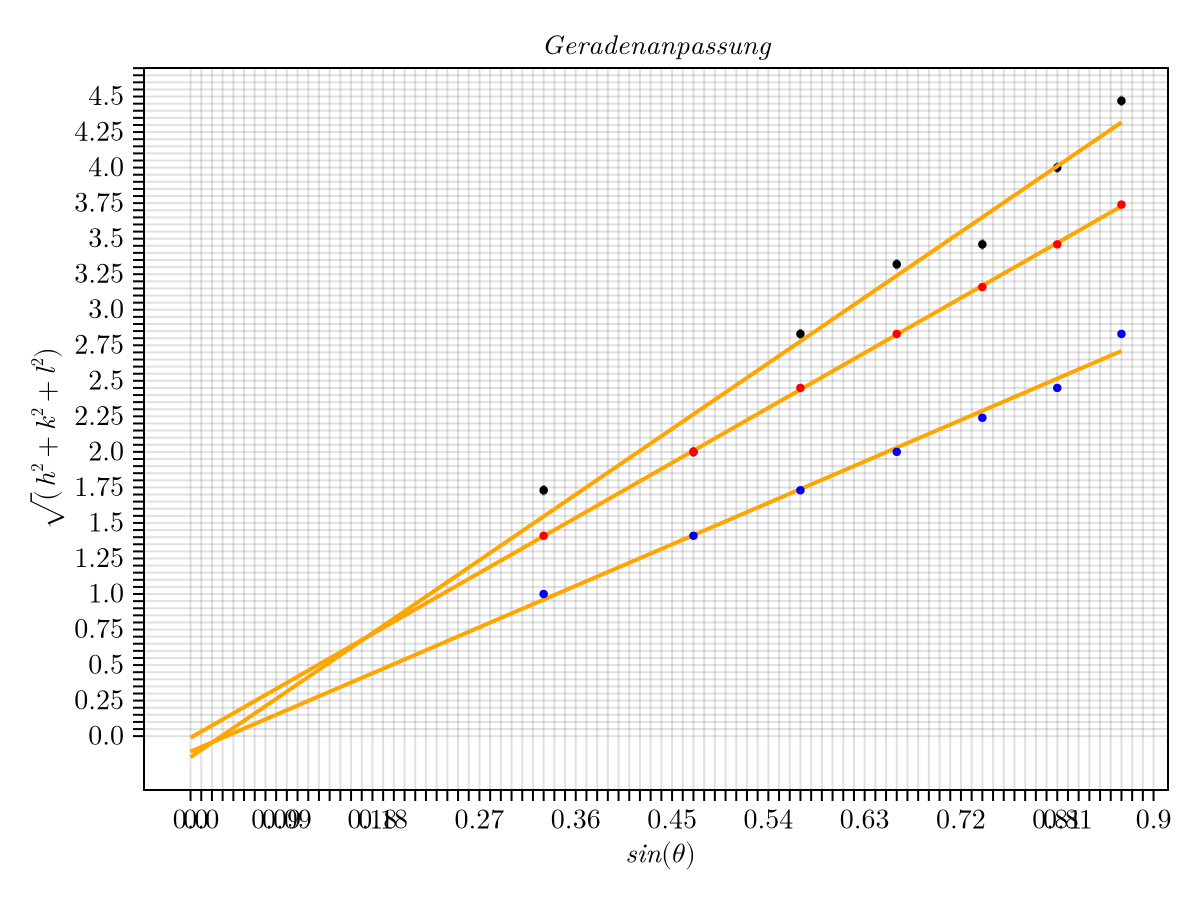

In [115]:
#x = th1
x = value.(th1)##ANPASSEN##
y1 = fcc ##ANPASSEN##
y2 = bcc ##ANPASSEN##
y3 = sc  ##ANPASSEN##
#Fehler-Array mit gleichem Fehler
yfit(x,m,b)=m*x+b
Δx= delth
Δy= 0   
fit1 = curve_fit(model, x, y1, p0)
fit2 = curve_fit(model, x, y2, p0)
fit3 = curve_fit(model, x, y3, p0)
p1=fit1.param
p2=fit2.param
p3=fit3.param
println("Die Steigung von Probe 3 ist ", p2[1]);
println("Die Steigung von Probe 2 ist ", p3[1]);
println("Die Steigung von Probe 1 ist ", p1[1]);
#=for i in 1:length(x)
    push!(Δx,ΔV) ###ANPASSEN##
    push!(Δy,ΔT) ##ANPASSEN##
end=#
#=for i in 1:length(x)
    push!(Δx,ΔV) ###ANPASSEN##
    push!(Δy,ΔT) ##ANPASSEN##
end=#

with_theme(theme_latexfonts()) do
    fig = Figure()
    ax = Axis(fig[1,1])
    #Fehlerbalken
    #errorbars!(ax, x, y, Δy, color=:grey, whiskerwidth = 5)
    errorbars!(ax, x, y1, Δx, color=:grey, whiskerwidth = 5, direction = :x)
    #Messwerte
    scatter!(ax,x, y1, markersize = 6, color=:black)
    lines!(ax, [0, x[end]], [p1[2], yfit(x[length(x)], p1[1], p1[2])], linewidth = 2, color = :orange)
    lines!(ax, [0, x[end]], [p2[2], yfit(x[length(x)], p2[1], p2[2])], linewidth = 2, color = :orange)
    lines!(ax, [0, x[end]], [p3[2], yfit(x[length(x)], p3[1], p3[2])], linewidth = 2, color = :orange)
    scatter!(ax,x, y2, markersize = 6, color=:red)
    scatter!(ax,x, y3, markersize = 6, color=:blue)
    
    ax.title = L"$Geradenanpassung$" ##ANPASSEN##


    #Skalierung der x-Achse ##ANPASSEN##
xticks = nice_ticks_and_labels(x, n_labels=11, n_ticks=10)[1]
xticklabels = nice_ticks_and_labels(x, n_labels=11, n_ticks=40)[2]
aligned_xlabels = alignedlabels(xticks, xticklabels)
#Skalierung der y-Achse ##ANPASSEN##
yticks = nice_ticks_and_labels(y1, n_labels=21)[1]
yticklabels = nice_ticks_and_labels(y1, n_labels=21)[2]   
aligned_ylabels = alignedlabels(yticks, yticklabels)
ax.xlabel = L" $sin(\theta)$" ##ANPASSEN##
ax.ylabel = L"$\sqrt(h^2 +k^2 +l^2)$  " ##ANPASSEN##

ax.xticks = (xticks, aligned_xlabels)
ax.yticks = (yticks, aligned_ylabels) 

#axislegend(ax; position=(:left, :top))
    #plot speichern
    save("Messung_gerade_Probe3.png", fig, px_per_unit = 2) ##ANPASSEN##

    fig
end
